# Sleep Efficiency Analysis

This notebook explores a dataset on sleep patterns to understand the factors that influence sleep efficiency. By analyzing variables such as age, bedtime, awakenings, alcohol consumption, and exercise frequency, we aim to build a statistical model that helps identify key contributors to a good night's rest.

## Set up

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
import numpy as np

## Part 1: Formulating a Research Question

I'd like to know how to get higher sleep efficiency which is the proportion of time in bed spent asleep. By getting more efficient sleep, people can enhance the efficiency during the day.

I will use the [Sleep Efficiency Dataset](https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency) in my analysis.

## Part 2: Data Exploration and Preparation

The dataset contains information about a group of test subjects and their sleep patterns. It includes 452 samples and updated 2 years ago.

It comes from [Kaggle](https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency).

Independent variables which I will use in this study:

- Age: Age of the test subject.
- Bedtime: The time the test subject goes to bed each night.
- Sleep duration: The total amount of time the test subject slept (in hours).
- Awakenings: The number of times the test subject wakes up during the night.
- Caffeine consumption: The amount of caffeine consumed in the 24 hours prior to bedtime (in mg)
- Alcohol consumption: The amount of alcohol consumed in the 24 hours prior to bedtime (in oz)
- Exercise frequency: The number of times the test subject exercises each week

Dependent variables:

- Sleep efficiency: A measure of the proportion of time in bed spent asleep.

### 1. Import the data set and select features

In [ ]:
drive.mount('/content/drive')
dataset = pd.read_csv('/content/drive/MyDrive/Datasets/Sleep_Efficiency.csv')
dataset = dataset[['Age', 'Bedtime', 'Sleep duration', 'Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Exercise frequency', 'Sleep efficiency']]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   452 non-null    int64  
 1   Bedtime               452 non-null    object 
 2   Sleep duration        452 non-null    float64
 3   Awakenings            432 non-null    float64
 4   Caffeine consumption  427 non-null    float64
 5   Alcohol consumption   438 non-null    float64
 6   Exercise frequency    446 non-null    float64
 7   Sleep efficiency      452 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 28.4+ KB


### 2. Rename columns

In [ ]:
dataset.rename(columns = {'Sleep duration': 'Sleep_duration',
                          'Caffeine consumption': 'Caffeine_consumption',
                          'Alcohol consumption': 'Alcohol_consumption',
                          "Exercise frequency": "Exercise_frequency",
                          'Sleep efficiency': "Sleep_efficiency"}, inplace = True)

### 3. Convert "Bedtime" to how many hours after 9:00 PM

In [ ]:
dataset["Bedtime"] = pd.to_datetime(dataset["Bedtime"]).dt.hour
dataset["Bedtime"] = np.where(dataset["Bedtime"] >= 21, dataset["Bedtime"] - 21, dataset["Bedtime"] + 3)

### 4. Visualization and Correlation Matrix

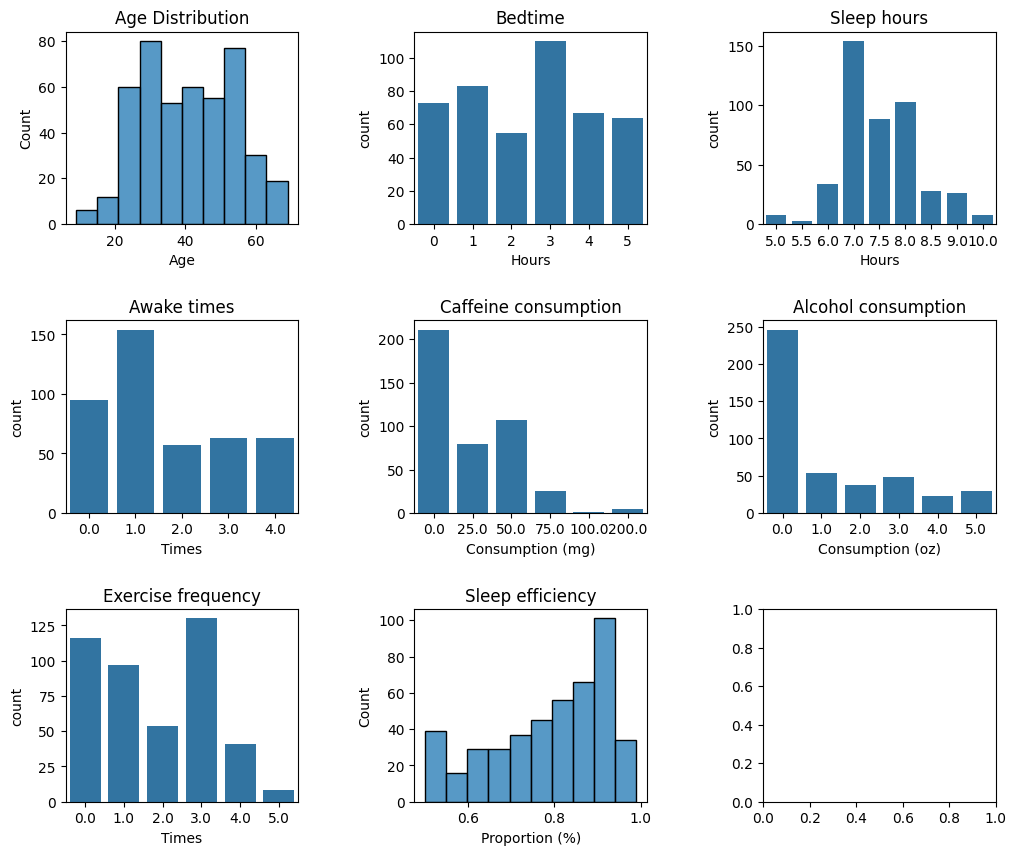

In [ ]:
fig, axs = plt.subplots(3, 3, figsize = (12, 10))

sns.histplot(data = dataset, x = 'Age', bins = 10, ax = axs[0, 0])
axs[0, 0].set_title("Age Distribution")

sns.barplot(x = dataset['Bedtime'].value_counts().index, y = dataset['Bedtime'].value_counts(), ax = axs[0, 1])
axs[0, 1].set_title("Bedtime")
axs[0, 1].set_xlabel("Hours")

sns.barplot(x = dataset['Sleep_duration'].value_counts().index, y = dataset['Sleep_duration'].value_counts(), ax = axs[0, 2])
axs[0, 2].set_title("Sleep hours")
axs[0, 2].set_xlabel("Hours")

sns.barplot(x = dataset['Awakenings'].value_counts().index, y = dataset['Awakenings'].value_counts(), ax = axs[1, 0])
axs[1, 0].set_title("Awake times")
axs[1, 0].set_xlabel("Times")

sns.barplot(x = dataset['Caffeine_consumption'].value_counts().index, y = dataset['Caffeine_consumption'].value_counts(), ax = axs[1, 1])
axs[1, 1].set_title("Caffeine consumption")
axs[1, 1].set_xlabel("Consumption (mg)")

sns.barplot(x = dataset['Alcohol_consumption'].value_counts().index, y = dataset['Alcohol_consumption'].value_counts(), ax = axs[1, 2])
axs[1, 2].set_title("Alcohol consumption")
axs[1, 2].set_xlabel("Consumption (oz)")

sns.barplot(x = dataset['Exercise_frequency'].value_counts().index, y = dataset['Exercise_frequency'].value_counts(), ax = axs[2, 0])
axs[2, 0].set_title("Exercise frequency")
axs[2, 0].set_xlabel("Times")

sns.histplot(data = dataset, x = 'Sleep_efficiency', ax = axs[2, 1])
axs[2, 1].set_title("Sleep efficiency")
axs[2, 1].set_xlabel("Proportion (%)")

plt.subplots_adjust(wspace=0.5, hspace=0.5)

plt.show()

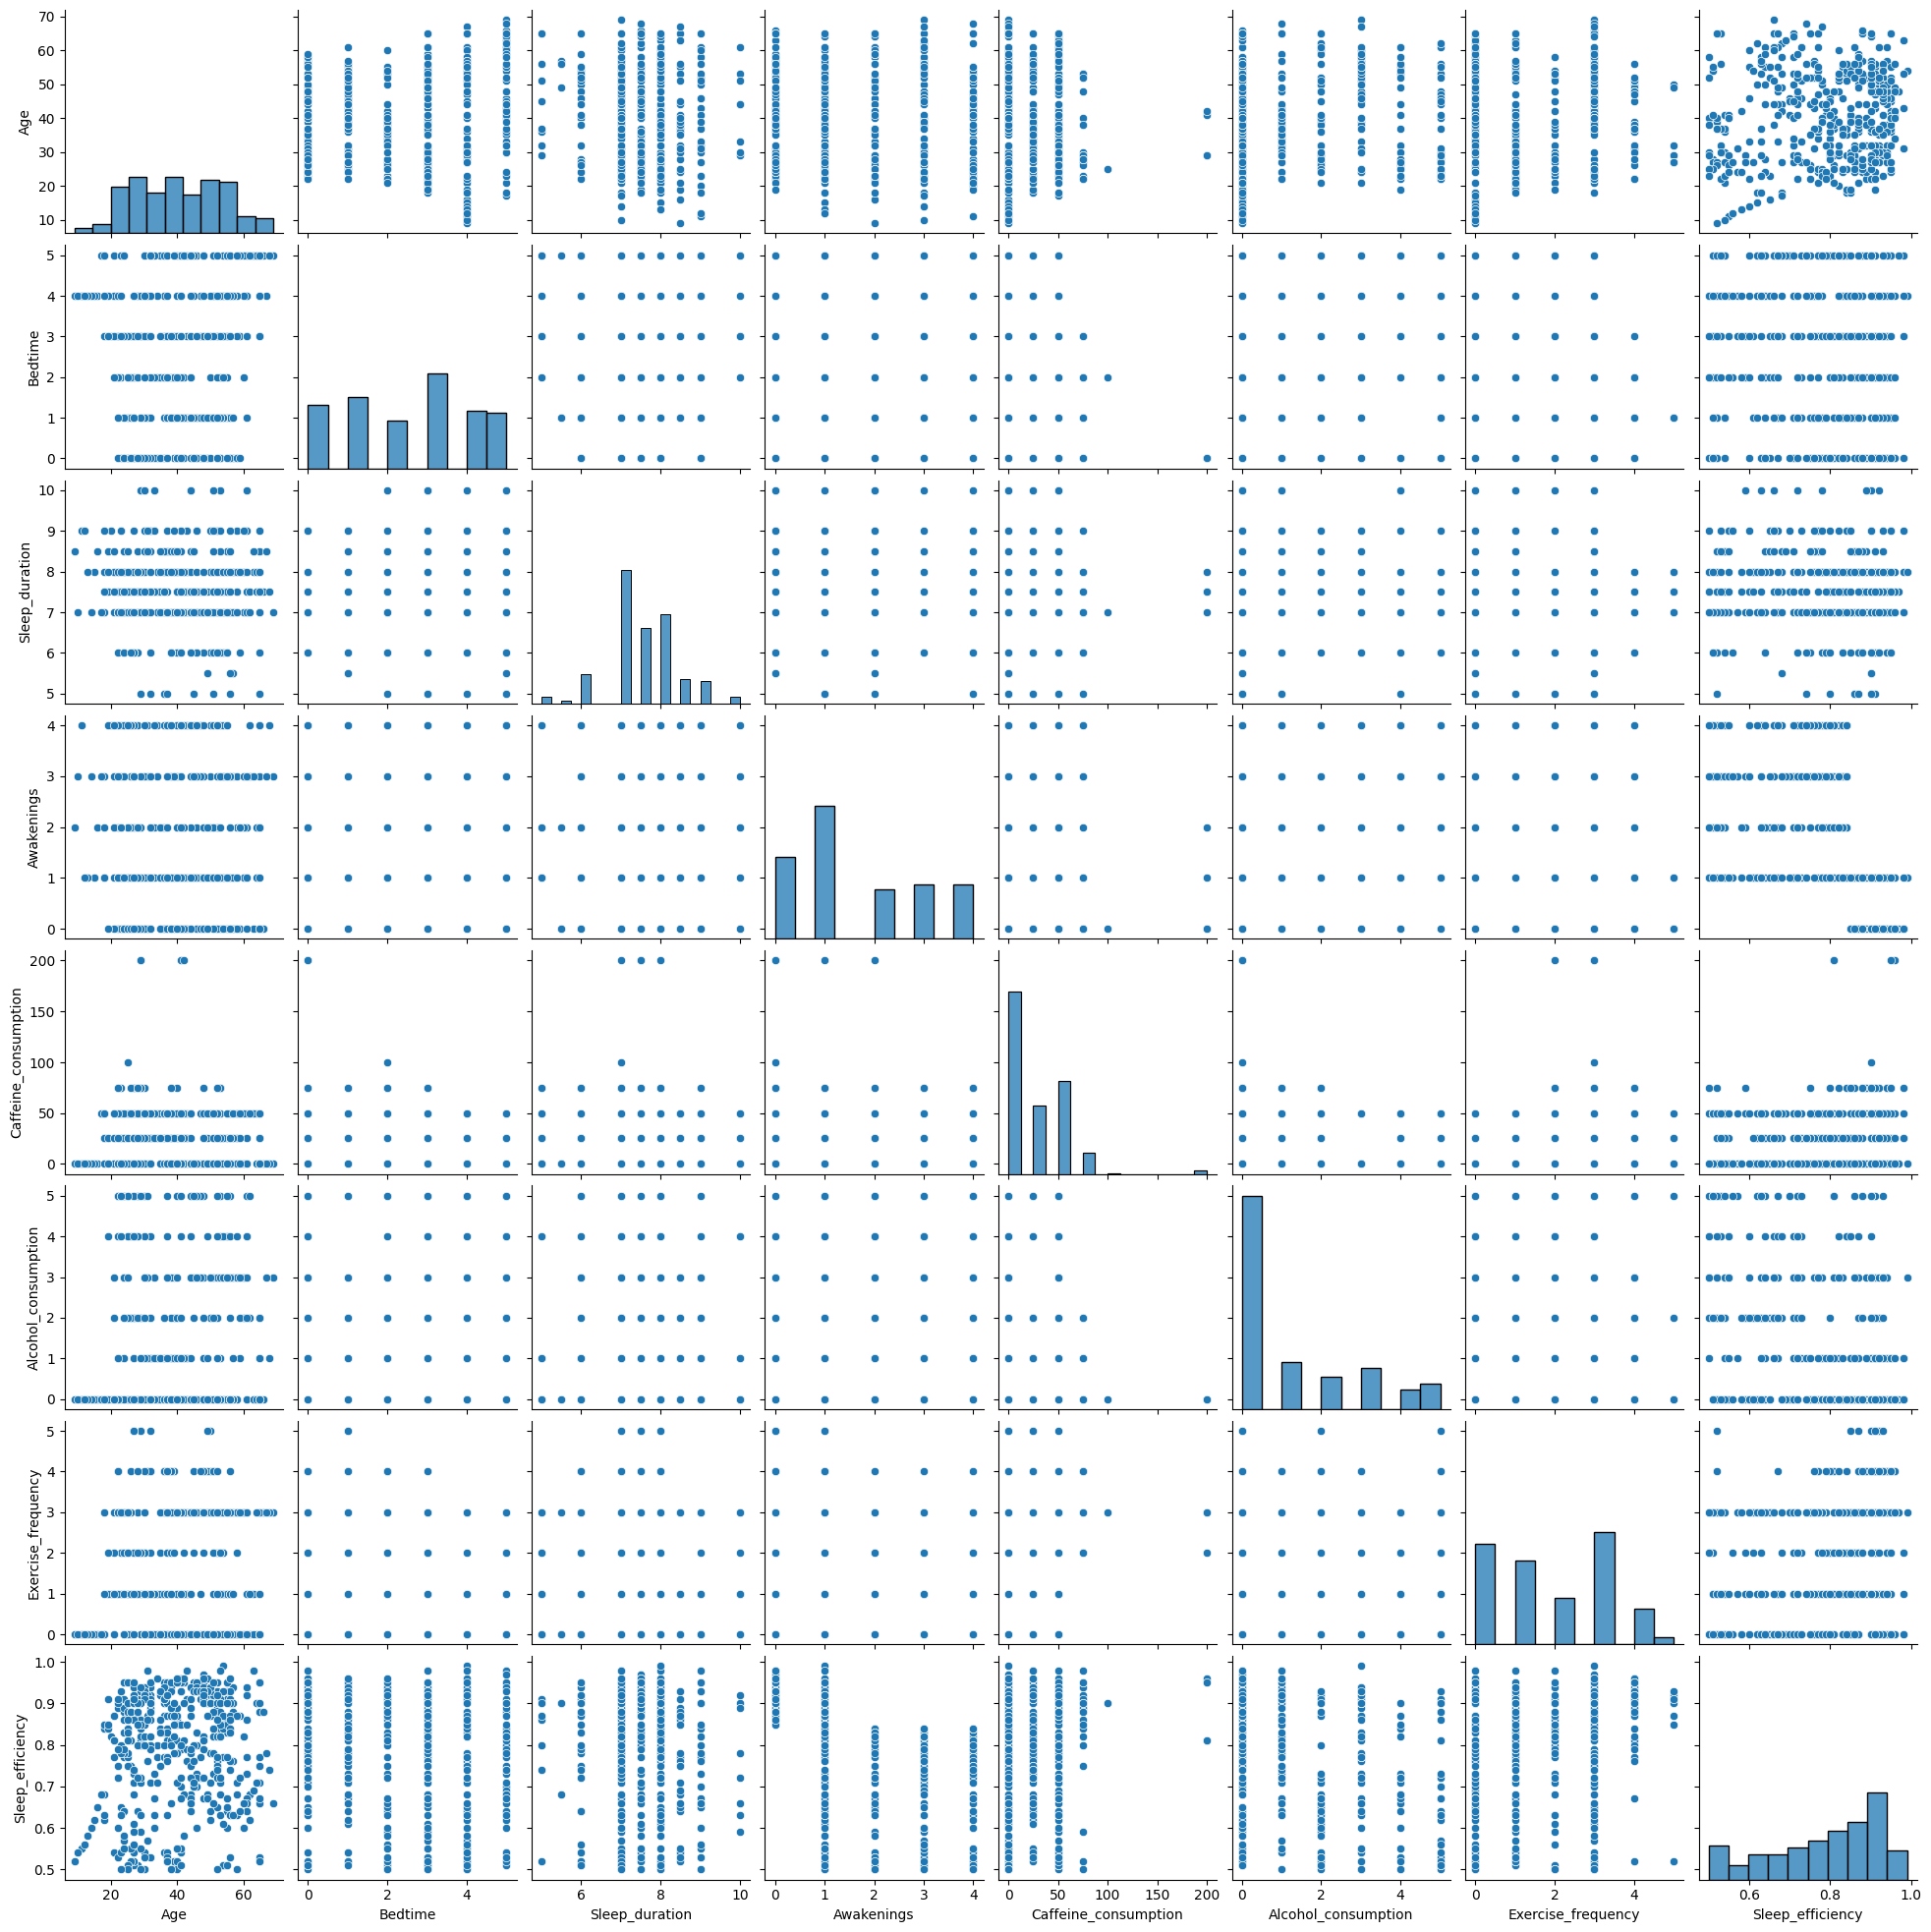

In [ ]:
sns.pairplot(dataset)
plt.show()

In [ ]:
dataset.corr()

,Age,Bedtime,Sleep_duration,Awakenings,Caffeine_consumption,Alcohol_consumption,Exercise_frequency,Sleep_efficiency
Age,1.000000,0.123524,-0.062462,-0.017789,-0.171460,0.047188,0.072308,0.098357
Bedtime,0.123524,1.000000,0.082124,0.112134,0.000940,0.029246,-0.324524,-0.151795
Sleep_duration,-0.062462,0.082124,1.000000,0.004939,-0.014802,-0.046243,-0.068272,-0.027467
Awakenings,-0.017789,0.112134,0.004939,1.000000,-0.108615,0.206090,-0.219578,-0.564979
Caffeine_consumption,-0.171460,0.000940,-0.014802,-0.108615,1.000000,-0.123308,-0.068224,0.065082
Alcohol_consumption,0.047188,0.029246,-0.046243,0.206090,-0.123308,1.000000,0.006934,-0.389624
Exercise_frequency,0.072308,-0.324524,-0.068272,-0.219578,-0.068224,0.006934,1.000000,0.259563
Sleep_efficiency,0.098357,-0.151795,-0.027467,-0.564979,0.065082,-0.389624,0.259563,1.000000


### 5. Normalization

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   452 non-null    int64  
 1   Bedtime               452 non-null    int32  
 2   Sleep_duration        452 non-null    float64
 3   Awakenings            432 non-null    float64
 4   Caffeine_consumption  427 non-null    float64
 5   Alcohol_consumption   438 non-null    float64
 6   Exercise_frequency    446 non-null    float64
 7   Sleep_efficiency      452 non-null    float64
dtypes: float64(6), int32(1), int64(1)
memory usage: 26.6 KB


In [ ]:
scaler = StandardScaler()
# Drop missing values before scaling to avoid errors
dataset.dropna(inplace=True)

dataset[['Age', 'Bedtime', 'Sleep_duration', 'Awakenings', 'Caffeine_consumption', 'Alcohol_consumption', 'Exercise_frequency']] = scaler.fit_transform(dataset[['Age', 'Bedtime', 'Sleep_duration', 'Awakenings', 'Caffeine_consumption', 'Alcohol_consumption', 'Exercise_frequency']])

In [ ]:
dataset.describe()

,Age,Bedtime,Sleep_duration,Awakenings,Caffeine_consumption,Alcohol_consumption,Exercise_frequency,Sleep_efficiency
count,4.520000e+02,4.520000e+02,4.520000e+02,4.320000e+02,4.270000e+02,4.380000e+02,446.000000,452.000000
mean,-2.947495e-17,3.929993e-17,7.073987e-17,4.111937e-18,-3.328069e-17,2.433366e-17,0.000000,0.788916
std,1.001108e+00,1.001108e+00,1.001108e+00,1.001159e+00,1.001173e+00,1.001144e+00,1.001123,0.135237
min,-2.377731e+00,-1.487482e+00,-2.848337e+00,-1.211050e+00,-7.840715e-01,-7.246052e-01,-1.255828,0.500000
25%,-8.577049e-01,-8.823140e-01,-5.379767e-01,-4.731463e-01,-7.840715e-01,-7.246052e-01,-1.255828,0.697500
50%,-2.169063e-02,3.280227e-01,3.961348e-02,-4.731463e-01,4.463773e-02,-7.246052e-01,0.146173,0.820000
75%,8.903249e-01,9.331910e-01,6.172036e-01,1.002660e+00,8.733469e-01,5.103250e-01,0.847173,0.900000
max,2.182347e+00,1.538359e+00,2.927564e+00,1.740564e+00,5.845602e+00,2.362720e+00,2.249174,0.990000


## Part 3: Linear Regression Analysis

### 1. Train a model

Use 'Age', 'Bedtime', 'Sleep_duration', 'Awakenings', 'Caffeine_consumption', 'Alcohol_consumption', 'Exercise_frequency' as X; 'Sleep_efficiency' as y to train a linear regression model.

In [ ]:
model = smf.ols('Sleep_efficiency ~ Age + Bedtime + Sleep_duration + Awakenings + Caffeine_consumption + Alcohol_consumption + Exercise_frequency', data = dataset).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Sleep_efficiency   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     44.85
Date:                Wed, 02 Apr 2025   Prob (F-statistic):           4.37e-46
Time:                        03:08:51   Log-Likelihood:                 341.72
No. Observations:                 388   AIC:                            -667.4
Df Residuals:                     380   BIC:                            -635.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.7873 

According to the summary, "Sleep_duration" and "Caffeine_consumption" don't have significant association with "Sleep_efficiency".

### 2. Refine the model with ANOVA

In [ ]:
anova = sm.stats.anova_lm(model, typ=2)
print(anova)

                        sum_sq     df           F        PR(>F)
Age                   0.150035    1.0   14.608117  1.545838e-04
Bedtime               0.048843    1.0    4.755609  2.981566e-02
Sleep_duration        0.000765    1.0    0.074474  7.850793e-01
Awakenings            1.333985    1.0  129.882920  4.415214e-26
Caffeine_consumption  0.005200    1.0    0.506253  4.772021e-01
Alcohol_consumption   0.626235    1.0   60.973081  5.690743e-14
Exercise_frequency    0.087841    1.0    8.552638  3.657043e-03
Residual              3.902856  380.0         NaN           NaN


We can remove "Sleep_duration" and "Caffeine_consumption".

In [ ]:
model_2 = smf.ols('Sleep_efficiency ~ Age + Bedtime + Awakenings + Alcohol_consumption + Exercise_frequency', data = dataset).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:       Sleep_efficiency   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     64.96
Date:                Wed, 02 Apr 2025   Prob (F-statistic):           9.97e-50
Time:                        03:18:01   Log-Likelihood:                 359.16
No. Observations:                 412   AIC:                            -706.3
Df Residuals:                     406   BIC:                            -682.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.7881    

In [ ]:
anova_2 = sm.stats.anova_lm(model_2, typ=2)
print(anova_2)

                       sum_sq     df           F        PR(>F)
Age                  0.115788    1.0   11.141859  9.218897e-04
Bedtime              0.034865    1.0    3.354899  6.773784e-02
Awakenings           1.493833    1.0  143.746788  1.457110e-28
Alcohol_consumption  0.692768    1.0   66.662794  4.105182e-15
Exercise_frequency   0.091807    1.0    8.834263  3.132253e-03
Residual             4.219200  406.0         NaN           NaN


We can remove "Bedtime" as well.

In [ ]:
model_3 = smf.ols('Sleep_efficiency ~ Age + Awakenings + Alcohol_consumption + Exercise_frequency', data = dataset).fit()
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:       Sleep_efficiency   R-squared:                       0.440
Model:                            OLS   Adj. R-squared:                  0.434
Method:                 Least Squares   F-statistic:                     79.90
Date:                Wed, 02 Apr 2025   Prob (F-statistic):           5.47e-50
Time:                        03:20:56   Log-Likelihood:                 357.47
No. Observations:                 412   AIC:                            -704.9
Df Residuals:                     407   BIC:                            -684.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.7880    

### 3. Check through Residual plots and normality plots

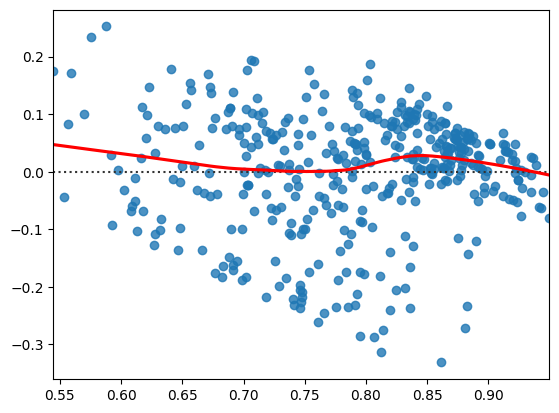

In [ ]:
sns.residplot(x = model_3.fittedvalues, y = model_3.resid, lowess = True, line_kws = {'color': 'red'})
plt.show()

There are patterns in residual.

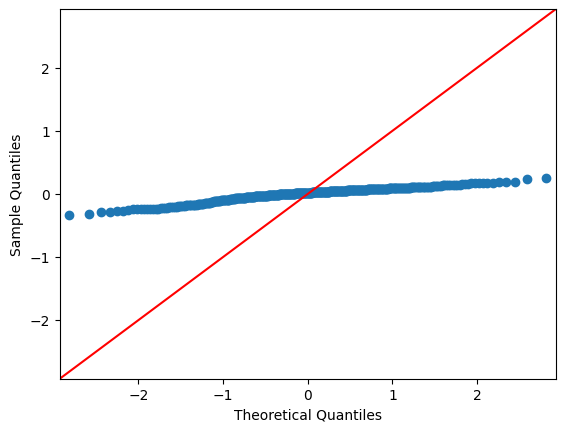

In [ ]:
sm.qqplot(model_3.resid, line ='45')
plt.show()

Residual doesn't follow normal distribution.

### 4. Check higher-order terms

In [ ]:
model_4 = smf.ols('Sleep_efficiency ~ Age + Awakenings + Alcohol_consumption + Exercise_frequency + I(Age ** 2) + I(Awakenings ** 2) + I(Alcohol_consumption ** 2)', data = dataset).fit()
print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:       Sleep_efficiency   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     62.43
Date:                Wed, 02 Apr 2025   Prob (F-statistic):           1.67e-60
Time:                        03:27:55   Log-Likelihood:                 389.12
No. Observations:                 412   AIC:                            -762.2
Df Residuals:                     404   BIC:                            -730.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [ ]:
model_5 = smf.ols('Sleep_efficiency ~ Age + Awakenings + Alcohol_consumption + Exercise_frequency + I(Age ** 2) + I(Awakenings ** 2) + I(Alcohol_consumption ** 2) + I(Awakenings ** 3)', data = dataset).fit()
print(model_5.summary())

                            OLS Regression Results                            
Dep. Variable:       Sleep_efficiency   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     55.76
Date:                Wed, 02 Apr 2025   Prob (F-statistic):           1.26e-60
Time:                        03:33:02   Log-Likelihood:                 391.60
No. Observations:                 412   AIC:                            -765.2
Df Residuals:                     403   BIC:                            -729.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [ ]:
model_6 = smf.ols('Sleep_efficiency ~ Age + Awakenings + Alcohol_consumption + Exercise_frequency + I(Age ** 2) + I(Awakenings ** 2) + I(Alcohol_consumption ** 2) + I(Awakenings ** 3) + I(Awakenings ** 4)', data = dataset).fit()
print(model_6.summary())

                            OLS Regression Results                            
Dep. Variable:       Sleep_efficiency   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.523
Method:                 Least Squares   F-statistic:                     51.09
Date:                Wed, 02 Apr 2025   Prob (F-statistic):           3.12e-61
Time:                        03:30:05   Log-Likelihood:                 395.18
No. Observations:                 412   AIC:                            -770.4
Df Residuals:                     402   BIC:                            -730.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

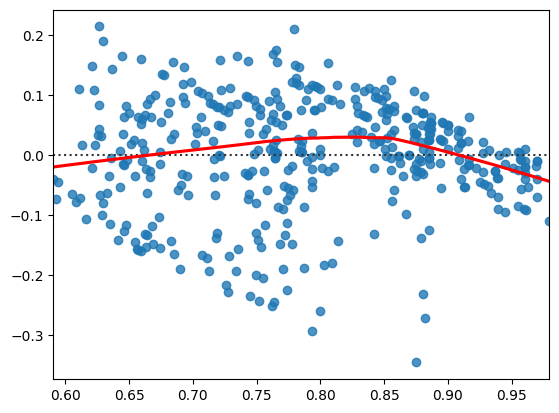

In [ ]:
sns.residplot(x = model_6.fittedvalues, y = model_6.resid, lowess = True, line_kws = {'color': 'red'})
plt.show()

There's still pattern in residual.

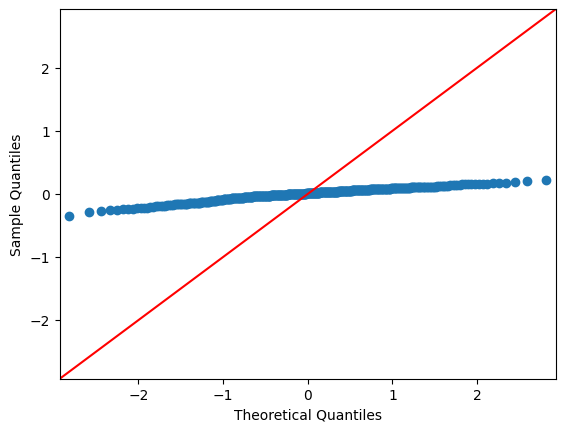

In [ ]:
sm.qqplot(model_6.resid, line ='45')
plt.show()

Residual still doesn't follow normal distribution.

### 5. Interpret the model

Older people and people doing ecercise more frequently have higher sleep efficiency.

Meanwhile, waking during sleep and consumpting alcohol have more significant negative association with sleep efficiency.

Thus, people can do exercise and avoid drinking alcohol before go to bed. And people can also reduce awakening times by setting proper temperature and avoiding drinking water before go to bed.

## Part 4: Discussion and Model Improvement

The R square is low (only 0.534) and there is a pattern in residual. They meight mean this model cannot represent the whole picture of the data set. Thus, I can use other kinds of model or find more features to improve the result.